# Random Forest Classification

This notebook builds a Random Forest model to predict the **Category** of a product purchase based on user demographics, purchase features, and temporal features.

**Key challenges:**
- 1,625 unique product categories (highly multi-class)
- Many rare categories (1,048 with < 50 samples)
- ~157K rows, 184 features
- Temporal train/test split (train ≤ 2021, test > 2021)

**Outline:**
1. Data loading and preparation
2. Baseline Random Forest
3. Feature importance analysis
4. Hyperparameter tuning
5. Final evaluation (precision, recall, F1)
6. Cross-validation

## 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [2]:
data = pd.read_csv('../data/cleaned_data.csv')
print(f'Dataset shape: {data.shape}')
print(f'Unique categories: {data["Category"].nunique()}')
data.head()

Dataset shape: (157026, 156)
Unique categories: 1625


,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Category,age,hispanic,education,income,howmany,...,"life-changes_Lost a job ,Divorce","life-changes_Lost a job ,Divorce,Moved place of residence","life-changes_Lost a job ,Had a child","life-changes_Lost a job ,Moved place of residence","life-changes_Lost a job ,Moved place of residence,Became pregnant","life-changes_Lost a job ,Moved place of residence,Became pregnant,Had a child","life-changes_Lost a job ,Moved place of residence,Had a child",life-changes_Moved place of residence,"life-changes_Moved place of residence,Became pregnant,Had a child","life-changes_Moved place of residence,Had a child"
0,7.98,1,83780,34099,586,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.99,1,16614,43470,729,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.45,1,73826,47343,432,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,10.00,1,77034,21023,1240,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.99,1,62681,39476,331,3,1,3,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Temporal train/test split
train = data[data['order_year'] <= 2021].copy()
test = data[data['order_year'] > 2021].copy()

print(f'Train size: {len(train):,} | Test size: {len(test):,}')
print(f'Train categories: {train["Category"].nunique()} | Test categories: {test["Category"].nunique()}')

# Check for categories in test that don't appear in training
train_cats = set(train['Category'].unique())
test_cats = set(test['Category'].unique())
unseen = test_cats - train_cats
print(f'Categories in test but not in train: {len(unseen)}')

Train size: 113,655 | Test size: 43,371
Train categories: 1601 | Test categories: 1458
Categories in test but not in train: 24


In [4]:
# Remove test samples with categories unseen during training
if len(unseen) > 0:
    test = test[~test['Category'].isin(unseen)]
    print(f'Removed {len(unseen)} unseen categories from test set.')
    print(f'Adjusted test size: {len(test):,}')

Removed 24 unseen categories from test set.
Adjusted test size: 43,329


In [5]:
# Drop non-predictive columns
drop_cols = ['Title', 'ASIN/ISBN (Product Code)']

X_train = train.drop(['Category'] + drop_cols, axis=1)
y_train = train['Category']

X_test = test.drop(['Category'] + drop_cols, axis=1)
y_test = test['Category']

print(f'Features: {X_train.shape[1]}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

Features: 153
X_train: (113655, 153) | X_test: (43329, 153)


In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler as training

print('Features scaled.')

Features scaled.


In [7]:
# Create subsampled versions for faster iteration
SUBSAMPLE_SIZE = 10_000

np.random.seed(42)
sub_idx = np.random.choice(len(X_train_scaled), size=min(SUBSAMPLE_SIZE, len(X_train_scaled)), replace=False)
X_train_sub = X_train_scaled[sub_idx]
y_train_sub = y_train.iloc[sub_idx]

print(f'Subsample size: {len(X_train_sub):,} (for quick experiments)')

Subsample size: 10,000 (for quick experiments)


## 2. Baseline Random Forest

We first train on the full dataset. If this is too slow, a subsampled fallback is provided below.

In [8]:
%%time

# Baseline model on subsampled training data
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=1,
    random_state=42,
    class_weight='balanced'
)

rf_baseline.fit(X_train_sub, y_train_sub)
print('Baseline model trained (on subsample).')

Baseline model trained (on subsample).
CPU times: total: 3.17 s
Wall time: 3.46 s


In [9]:
# Baseline predictions and metrics
y_pred_baseline = rf_baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_f1_macro = f1_score(y_test, y_pred_baseline, average='macro', zero_division=0)
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

print(f'Baseline Accuracy:         {baseline_acc:.4f}')
print(f'Baseline F1 (macro):       {baseline_f1_macro:.4f}')
print(f'Baseline F1 (weighted):    {baseline_f1_weighted:.4f}')

Baseline Accuracy:         0.0118
Baseline F1 (macro):       0.0056
Baseline F1 (weighted):    0.0122


In [10]:
# Subsample fallback — uncomment and run these cells if full training is too slow

# %%time
# rf_baseline = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=30,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     n_jobs=-1,
#     random_state=42,
#     class_weight='balanced'
# )
# rf_baseline.fit(X_train_sub, y_train_sub)
# y_pred_baseline = rf_baseline.predict(X_test_scaled)
# print(f'Subsample Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}')

## 3. Feature Importance Analysis

In [11]:
# Feature importances from baseline model
feature_names = X_train.columns
importances = rf_baseline.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 20 most important features:')
feat_imp.head(20)

Top 20 most important features:


,Feature,Importance
0,Purchase Price Per Unit,0.162028
10,order_day,0.147845
9,order_month,0.126529
11,order_year,0.089270
5,income,0.030759
2,age,0.027764
7,hh-size,0.022183
4,education,0.021600
8,how-oft,0.018613
6,howmany,0.018058


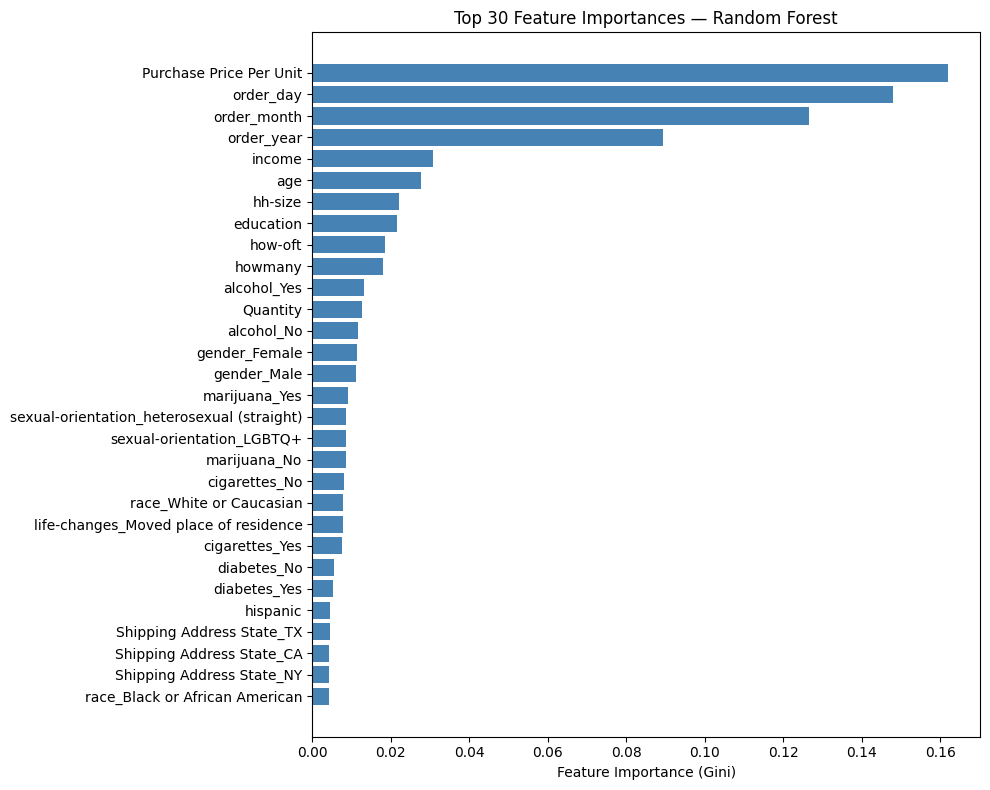

In [12]:
# Plot top 30 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 30
top_feats = feat_imp.head(top_n)

ax.barh(range(top_n), top_feats['Importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 30 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

Features needed for 90% importance: 54 / 153
Features needed for 95% importance: 80 / 153


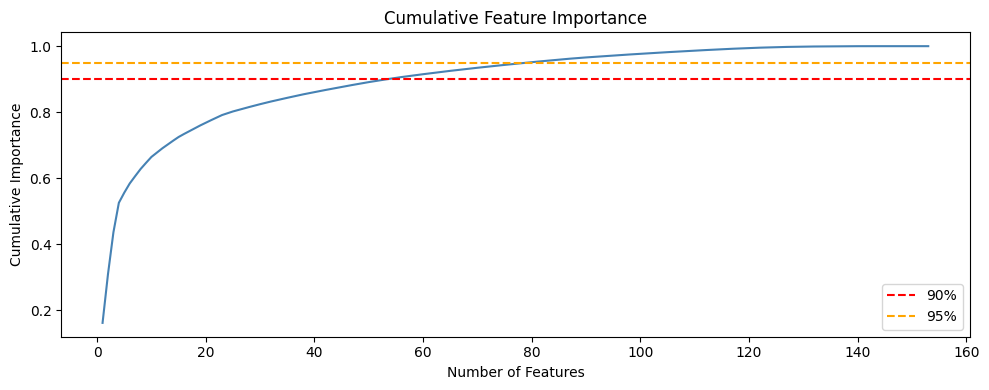

In [13]:
# Cumulative importance
feat_imp['Cumulative'] = feat_imp['Importance'].cumsum()

n_90 = (feat_imp['Cumulative'] <= 0.90).sum() + 1
n_95 = (feat_imp['Cumulative'] <= 0.95).sum() + 1

print(f'Features needed for 90% importance: {n_90} / {len(feature_names)}')
print(f'Features needed for 95% importance: {n_95} / {len(feature_names)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(feat_imp) + 1), feat_imp['Cumulative'].values, color='steelblue')
ax.axhline(y=0.90, color='r', linestyle='--', label='90%')
ax.axhline(y=0.95, color='orange', linestyle='--', label='95%')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Cumulative Importance')
ax.set_title('Cumulative Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning

We use `RandomizedSearchCV` to efficiently explore the hyperparameter space. This runs on the subsample to keep runtime manageable.

In [ ]:
%%time

param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_search = RandomForestClassifier(n_jobs=1, random_state=42)

random_search = RandomizedSearchCV(
    rf_search,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_train_sub, y_train_sub)

print(f'\nBest score (F1 weighted): {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [ ]:
# View all search results
search_results = pd.DataFrame(random_search.cv_results_)
search_results = search_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
search_results.sort_values('rank_test_score').head(10)

,params,mean_test_score,std_test_score,rank_test_score
11,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.068329,0.002339,1
1,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.064494,0.002915,2
6,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.061293,0.000613,3
9,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.058243,0.004129,4
13,"{'n_estimators': 50, 'min_samples_split': 5, '...",0.057667,0.002220,5
3,"{'n_estimators': 200, 'min_samples_split': 10,...",0.051963,0.003562,6
14,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.036849,0.001653,7
5,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.036054,0.002644,8
10,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.034349,0.000871,9
4,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.033169,0.001181,10


## 5. Tuned Model — Full Training and Evaluation

In [ ]:
%%time

# Train tuned model on subsample
best_params = random_search.best_params_
print(f'Training tuned model with: {best_params}')

rf_tuned = RandomForestClassifier(
    **best_params,
    n_jobs=1,
    random_state=42
)

rf_tuned.fit(X_train_sub, y_train_sub)
print('Tuned model trained.')

In [ ]:
# Tuned model predictions and metrics
y_pred_tuned = rf_tuned.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec_macro = precision_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_rec_macro = recall_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_macro = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print('=== Tuned Random Forest Results ===')
print(f'Accuracy:             {tuned_acc:.4f}')
print(f'Precision (macro):    {tuned_prec_macro:.4f}')
print(f'Recall (macro):       {tuned_rec_macro:.4f}')
print(f'F1 Score (macro):     {tuned_f1_macro:.4f}')
print(f'F1 Score (weighted):  {tuned_f1_weighted:.4f}')

print(f'\n--- Comparison ---')
print(f'Baseline accuracy:    {baseline_acc:.4f}')
print(f'Tuned accuracy:       {tuned_acc:.4f}')
print(f'Improvement:          {tuned_acc - baseline_acc:+.4f}')

In [ ]:
# Per-class classification report (top 20 most frequent categories)
top_20_cats = y_test.value_counts().head(20).index.tolist()
mask = y_test.isin(top_20_cats)

print('Classification Report — Top 20 Most Frequent Categories:')
print(classification_report(
    y_test[mask], y_pred_tuned[mask],
    labels=top_20_cats,
    zero_division=0
))

In [ ]:
# Confusion matrix for top 15 categories
top_15_cats = y_test.value_counts().head(15).index.tolist()
mask_15 = y_test.isin(top_15_cats)

cm = confusion_matrix(y_test[mask_15], y_pred_tuned[mask_15], labels=top_15_cats)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_15_cats, yticklabels=top_15_cats, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Top 15 Categories')
plt.tight_layout()
plt.show()

## 6. Cross-Validation

Stratified K-Fold cross-validation on the subsample to estimate model generalization.

In [ ]:
%%time

# Filter subsample to categories with enough members for stratified splits
sub_df = pd.DataFrame(X_train_sub, columns=feature_names)
sub_df['Category'] = y_train_sub.values

cat_counts = sub_df['Category'].value_counts()
valid_cats = cat_counts[cat_counts >= 5].index
sub_df_filtered = sub_df[sub_df['Category'].isin(valid_cats)]

X_cv = sub_df_filtered.drop('Category', axis=1).values
y_cv = sub_df_filtered['Category'].values

print(f'CV subset: {len(X_cv):,} samples, {len(valid_cats)} categories (filtered to >= 5 samples per class)')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    **best_params,
    n_jobs=1,
    random_state=42
)

cv_scores = cross_val_score(rf_cv, X_cv, y_cv, cv=cv, scoring='f1_weighted', n_jobs=1)

print(f'\nCV F1 (weighted) scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

In [ ]:
# Also compute CV accuracy
cv_acc_scores = cross_val_score(rf_cv, X_cv, y_cv, cv=cv, scoring='accuracy', n_jobs=1)

print(f'CV Accuracy scores: {cv_acc_scores}')
print(f'Mean: {cv_acc_scores.mean():.4f} (+/- {cv_acc_scores.std() * 2:.4f}')

## 7. Summary

In [ ]:
print('=' * 55)
print('        RANDOM FOREST — RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset:              {data.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'  Categories:           {data["Category"].nunique()}')
print(f'  Train subsample:      {len(y_train_sub):,}')
print(f'  Test set:             {len(y_test):,}')
print(f'')
print(f'  --- Baseline (default RF) ---')
print(f'  Accuracy:             {baseline_acc:.4f}')
print(f'  F1 (weighted):        {baseline_f1_weighted:.4f}')
print(f'')
print(f'  --- Tuned RF ---')
print(f'  Best params:          {best_params}')
print(f'  Accuracy:             {tuned_acc:.4f}')
print(f'  Precision (macro):    {tuned_prec_macro:.4f}')
print(f'  Recall (macro):       {tuned_rec_macro:.4f}')
print(f'  F1 (macro):           {tuned_f1_macro:.4f}')
print(f'  F1 (weighted):        {tuned_f1_weighted:.4f}')
print(f'')
print(f'  --- Cross-Validation (5-fold, subsample) ---')
print(f'  F1 (weighted):        {cv_scores.mean():.4f} +/- {cv_scores.std() * 2:.4f}')
print(f'  Accuracy:             {cv_acc_scores.mean():.4f} +/- {cv_acc_scores.std() * 2:.4f}')
print('=' * 55)